In [36]:
import pandas as pd
vms = pd.read_excel(r"C:\Users\Prabhat\Desktop\Carear\Hackathons\CFL_External Data Pack_Phase1.ods", sheet_name="VMS", skiprows=2)
vms = vms.rename(columns={'Unnamed: 0': 'cost_rank', 'Unnamed: 1': 'PLID_masked','Unnamed: 2':'VMS_top_name'})
vms

,cost_rank,PLID_masked,VMS_top_name,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
0,1,SWITCH Enterprise 48-Port UPOE,Education- Public/Private,618.0,1090.0,1024.0,834.0,866.0,583.0,1437.0,664.0,421.0,1093.0,646.0,1078.0,618.0
1,1,SWITCH Enterprise 48-Port UPOE,Energy/Utilities,377.0,413.0,499.0,299.0,500.0,365.0,345.0,361.0,649.0,222.0,244.0,304.0,289.0
2,1,SWITCH Enterprise 48-Port UPOE,Financial Services,1175.0,2947.0,959.0,1300.0,1032.0,946.0,1173.0,1568.0,1065.0,936.0,1688.0,1060.0,738.0
3,1,SWITCH Enterprise 48-Port UPOE,Government,4579.0,4994.0,1827.0,3762.0,5377.0,2059.0,3320.0,5709.0,3438.0,3021.0,2488.0,4111.0,3682.0
4,1,SWITCH Enterprise 48-Port UPOE,Health Care,5269.0,4463.0,2137.0,4334.0,2266.0,1820.0,2550.0,3162.0,3499.0,4353.0,2807.0,3060.0,2253.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
417,30,ROUTER Branch 8-Port PoE,Service Provider,0.0,6.0,6.0,1.0,0.0,5.0,26.0,1.0,5.0,26.0,1.0,9.0,1.0
418,30,ROUTER Branch 8-Port PoE,Technical Services,0.0,0.0,64.0,6.0,7.0,5.0,15.0,1.0,18.0,23.0,18.0,15.0,35.0
419,30,ROUTER Branch 8-Port PoE,Transportation,0.0,NaN,0.0,1.0,0.0,35.0,1.0,1.0,3.0,6.0,2.0,1.0,NaN
420,30,ROUTER Branch 8-Port PoE,Unknown,130.0,40.0,45.0,9.0,74.0,158.0,127.0,109.0,200.0,217.0,179.0,91.0,84.0


In [37]:

scms = pd.read_excel(r"C:\Users\Prabhat\Desktop\Carear\Hackathons\CFL_External Data Pack_Phase1.ods", sheet_name="SCMS", skiprows=2)
scms = scms.rename(columns={'Unnamed: 0': 'cost_rank', 'Unnamed: 1': 'PLID_masked','Unnamed: 2':'sales_coverage_code'})
scms

,cost_rank,PLID_masked,sales_coverage_code,2023Q1,2023Q2,2023Q3,2023Q4,2024Q1,2024Q2,2024Q3,2024Q4,2025Q1,2025Q2,2025Q3,2025Q4,2026Q1
0,1,SWITCH Enterprise 48-Port UPOE,COMMERCIAL,1583.5,2570.0,1481.0,2726.5,955.16,1216.4,1576.0,2347.0,1244.0,1888.25,1373.5,1990.0,937.9472
1,1,SWITCH Enterprise 48-Port UPOE,ENTERPRISE,6329.5,7274.5,2531.0,4107.5,2825.84,2482.5,3448.5,3683.0,3835.6,5856.45,4716.0,3720.4,2983.0528
2,1,SWITCH Enterprise 48-Port UPOE,OTHER,7009.0,6310.0,3381.0,3877.0,5608.00,3284.0,4619.0,6400.0,5275.0,4797.00,4438.0,4619.0,4070.0000
3,1,SWITCH Enterprise 48-Port UPOE,PUBLIC SECTOR,3597.0,4658.0,3899.0,5113.0,2881.00,1932.9,4331.0,5284.0,3357.4,2861.80,2895.0,4684.6,3438.0000
4,1,SWITCH Enterprise 48-Port UPOE,SERVICE PROVIDER,2650.0,270.0,-779.0,110.0,58.00,414.0,3446.0,717.0,840.0,784.00,802.0,3512.0,1670.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,30,ROUTER Branch 8-Port PoE,ENTERPRISE,60.0,44.0,403.0,28.0,68.00,64.0,67.0,90.0,86.0,608.00,1020.0,962.0,127.0000
170,30,ROUTER Branch 8-Port PoE,OTHER,94.0,131.0,61.0,53.0,112.00,249.0,252.0,193.0,333.0,350.00,209.0,753.0,614.0000
171,30,ROUTER Branch 8-Port PoE,PUBLIC SECTOR,21.0,576.0,150.0,167.0,352.00,98.0,655.0,47.3,433.6,269.00,98.0,135.0,209.4000
172,30,ROUTER Branch 8-Port PoE,SERVICE PROVIDER,0.0,2.0,5.0,1.0,0.00,117.0,-46.0,2.0,6.0,29.00,152.0,179.0,2.0000


In [38]:
# STEP 3: Identify quarter columns
# -------------------------------
quarter_cols = [col for col in vms.columns if "Q" in col]

# -------------------------------
# STEP 4: Unpivot (melt)
# -------------------------------
df_long = vms.melt(
    id_vars=["cost_rank", "PLID_masked", "VMS_top_name"],
    value_vars=quarter_cols,
    var_name="Quarter",
    value_name="Units"
)

# -------------------------------
# STEP 5: Split Year & Quarter
# -------------------------------
df_long["Year"] = df_long["Quarter"].str[:4].astype(int)
df_long["Q"] = df_long["Quarter"].str[-1].astype(int)

# -------------------------------
# STEP 6: Create Time Index
# -------------------------------
df_long["Time_Index"] = (
    (df_long["Year"] - df_long["Year"].min()) * 4 + df_long["Q"]
)

# -------------------------------
# STEP 7: Compute total units per product per quarter
# -------------------------------
total_df = df_long.groupby(
    ["PLID_masked", "Year", "Q"]
)["Units"].sum().reset_index(name="Total_Units")

# -------------------------------
# STEP 8: Merge total back
# -------------------------------
df_long = df_long.merge(
    total_df,
    on=["PLID_masked", "Year", "Q"]
)

# -------------------------------
# STEP 9: Create VMS ratio
# -------------------------------
df_long["VMS_ratio"] = df_long["Units"] / df_long["Total_Units"]
total_units = df_long.groupby(
    ["PLID_masked", "Year", "Q", "Time_Index"]
)["Units"].sum().reset_index(name="Total_Units")
# -------------------------------
# STEP 10: Pivot to ML features
# -------------------------------
df_VMS_features = df_long.pivot_table(
    index=["PLID_masked", "Year", "Q", "Time_Index"],
    columns="VMS_top_name",
    values="VMS_ratio",
    fill_value=0
).reset_index()

# -------------------------------
# DONE ✅
# -------------------------------
df_VMS_features



VMS_top_name,PLID_masked,Year,Q,Time_Index,Education- Public/Private,Energy/Utilities,Financial Services,Government,Health Care,Hospitality/Hotels & Leisure,Manufacturing,Media/Entertainment,Professional Services,Retail,Service Provider,Technical Services,Transportation,Unknown,Wholesale/Distribution
0,IP CONFERENCE PHONE,2023,1,1,0.024822,0.014624,0.149124,0.390225,0.038099,0.000385,0.164133,0.001155,0.054839,0.008659,0.003271,0.038869,-0.054647,0.162786,0.003656
1,IP CONFERENCE PHONE,2023,2,2,0.045082,0.033177,0.296448,0.375683,0.028493,0.001561,0.115535,0.003123,0.038837,0.008197,0.004098,0.024395,-0.015222,0.035714,0.004879
2,IP CONFERENCE PHONE,2023,3,3,0.088353,0.067699,0.083190,0.339357,0.037866,0.000287,0.153471,0.004303,0.070855,0.012335,0.001434,0.011474,0.022949,0.096099,0.010327
3,IP CONFERENCE PHONE,2023,4,4,0.025194,0.033915,0.154070,0.359738,0.078973,0.000000,0.121609,0.005572,0.058866,0.006783,0.000484,0.004118,0.015019,0.130814,0.004845
4,IP CONFERENCE PHONE,2024,1,5,0.007086,0.035430,0.065157,0.375389,0.038714,0.002938,0.125648,0.001555,0.039060,0.016592,0.025752,0.011061,0.005358,0.244210,0.006049
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,1,9,0.160368,0.022702,0.140589,0.222156,0.048100,0.000805,0.107735,0.013653,0.082897,0.017976,0.018396,0.027796,0.016909,0.103586,0.016331
359,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,2,10,0.175310,0.030552,0.116190,0.200791,0.044599,0.000679,0.075458,0.012088,0.080836,0.017594,0.005877,0.010897,0.012229,0.211701,0.005199
360,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,3,11,0.260237,0.018692,0.140842,0.157281,0.076033,0.000171,0.056271,0.003461,0.050727,0.010917,0.025341,0.015357,0.009153,0.164043,0.011475
361,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,4,12,0.215612,0.010015,0.112793,0.231250,0.037905,0.000140,0.073712,0.007161,0.053557,0.011917,0.002476,0.019792,0.006602,0.208325,0.008742


In [39]:
df_long

,cost_rank,PLID_masked,VMS_top_name,Quarter,Units,Year,Q,Time_Index,Total_Units,VMS_ratio
0,1,SWITCH Enterprise 48-Port UPOE,Education- Public/Private,2023Q1,618.0,2023,1,1,21246.0,0.029088
1,1,SWITCH Enterprise 48-Port UPOE,Energy/Utilities,2023Q1,377.0,2023,1,1,21246.0,0.017745
2,1,SWITCH Enterprise 48-Port UPOE,Financial Services,2023Q1,1175.0,2023,1,1,21246.0,0.055305
3,1,SWITCH Enterprise 48-Port UPOE,Government,2023Q1,4579.0,2023,1,1,21246.0,0.215523
4,1,SWITCH Enterprise 48-Port UPOE,Health Care,2023Q1,5269.0,2023,1,1,21246.0,0.248000
...,...,...,...,...,...,...,...,...,...,...
5481,30,ROUTER Branch 8-Port PoE,Service Provider,2026Q1,1.0,2026,1,13,1208.0,0.000828
5482,30,ROUTER Branch 8-Port PoE,Technical Services,2026Q1,35.0,2026,1,13,1208.0,0.028974
5483,30,ROUTER Branch 8-Port PoE,Transportation,2026Q1,NaN,2026,1,13,1208.0,NaN
5484,30,ROUTER Branch 8-Port PoE,Unknown,2026Q1,84.0,2026,1,13,1208.0,0.069536


In [40]:
quarter_cols = [col for col in scms.columns if "Q" in col]

# -------------------------------
# STEP 4: Melt (unpivot)
# -------------------------------
df_scms_long = scms.melt(
    id_vars=["cost_rank", "PLID_masked", "sales_coverage_code"],
    value_vars=quarter_cols,
    var_name="Quarter",
    value_name="Units"
)

# -------------------------------
# STEP 5: Split Year & Quarter
# -------------------------------
df_scms_long["Year"] = df_scms_long["Quarter"].str[:4].astype(int)
df_scms_long["Q"] = df_scms_long["Quarter"].str[-1].astype(int)

# -------------------------------
# STEP 6: Create Time Index
# -------------------------------
df_scms_long["Time_Index"] = (
    (df_scms_long["Year"] - df_scms_long["Year"].min()) * 4 + df_scms_long["Q"]
)

# -------------------------------
# STEP 7: Compute total units
# -------------------------------
total_scms = df_scms_long.groupby(
    ["PLID_masked", "Year", "Q"]
)["Units"].sum().reset_index(name="Total_Units")

# -------------------------------
# STEP 8: Merge totals
# -------------------------------
df_scms_long = df_scms_long.merge(
    total_scms,
    on=["PLID_masked", "Year", "Q"]
)

# -------------------------------
# STEP 9: Create SCMS ratios
# -------------------------------
df_scms_long["SCMS_ratio"] = df_scms_long["Units"] / df_scms_long["Total_Units"]

# -------------------------------
# STEP 10: Pivot to features
# -------------------------------
df_SCMS_features = df_scms_long.pivot_table(
    index=["PLID_masked", "Year", "Q", "Time_Index"],
    columns="sales_coverage_code",
    values="SCMS_ratio",
    fill_value=0
).reset_index()

# -------------------------------
# CLEAN column names (optional)
# -------------------------------
df_SCMS_features.columns = df_SCMS_features.columns.str.replace(" ", "_")

df_SCMS_features

sales_coverage_code,PLID_masked,Year,Q,Time_Index,COMMERCIAL,ENTERPRISE,OTHER,PUBLIC_SECTOR,SERVICE_PROVIDER,SMB
0,IP CONFERENCE PHONE,2023,1,1,0.047335,0.118915,0.530883,0.287281,0.004233,0.011353
1,IP CONFERENCE PHONE,2023,2,2,0.050156,0.269711,0.200234,0.453942,0.010343,0.015613
2,IP CONFERENCE PHONE,2023,3,3,0.106139,0.144291,0.393861,0.339071,0.002295,0.014343
3,IP CONFERENCE PHONE,2023,4,4,0.098716,0.137112,0.390504,0.365795,0.000484,0.007389
4,IP CONFERENCE PHONE,2024,1,5,0.058935,0.084514,0.547010,0.275320,0.025579,0.008642
...,...,...,...,...,...,...,...,...,...,...
358,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,1,9,0.093006,0.185206,0.351665,0.347185,0.010852,0.012086
359,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,2,10,0.109999,0.082335,0.455158,0.335441,0.008323,0.008744
360,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,3,11,0.064530,0.169032,0.411461,0.344077,0.001776,0.009124
361,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,4,12,0.074125,0.139508,0.384941,0.385641,0.002581,0.013204


In [41]:
merged_df = df_VMS_features.merge(
    df_SCMS_features,
    on=["PLID_masked", "Year", "Q", "Time_Index"],
    how="inner"
)
# -------------------------------
# ADD TARGET BACK
# -------------------------------
merged_df = merged_df.merge(
    total_units,
    on=["PLID_masked", "Year", "Q", "Time_Index"],
    how="inner"
)
merged_df

,PLID_masked,Year,Q,Time_Index,Education- Public/Private,Energy/Utilities,Financial Services,Government,Health Care,Hospitality/Hotels & Leisure,...,Transportation,Unknown,Wholesale/Distribution,COMMERCIAL,ENTERPRISE,OTHER,PUBLIC_SECTOR,SERVICE_PROVIDER,SMB,Total_Units
0,IP CONFERENCE PHONE,2023,1,1,0.024822,0.014624,0.149124,0.390225,0.038099,0.000385,...,-0.054647,0.162786,0.003656,0.047335,0.118915,0.530883,0.287281,0.004233,0.011353,5197.0
1,IP CONFERENCE PHONE,2023,2,2,0.045082,0.033177,0.296448,0.375683,0.028493,0.001561,...,-0.015222,0.035714,0.004879,0.050156,0.269711,0.200234,0.453942,0.010343,0.015613,5124.0
2,IP CONFERENCE PHONE,2023,3,3,0.088353,0.067699,0.083190,0.339357,0.037866,0.000287,...,0.022949,0.096099,0.010327,0.106139,0.144291,0.393861,0.339071,0.002295,0.014343,3486.0
3,IP CONFERENCE PHONE,2023,4,4,0.025194,0.033915,0.154070,0.359738,0.078973,0.000000,...,0.015019,0.130814,0.004845,0.098716,0.137112,0.390504,0.365795,0.000484,0.007389,4128.0
4,IP CONFERENCE PHONE,2024,1,5,0.007086,0.035430,0.065157,0.375389,0.038714,0.002938,...,0.005358,0.244210,0.006049,0.058935,0.084514,0.547010,0.275320,0.025579,0.008642,5786.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,1,9,0.160368,0.022702,0.140589,0.222156,0.048100,0.000805,...,0.016909,0.103586,0.016331,0.093006,0.185206,0.351665,0.347185,0.010852,0.012086,57131.0
359,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,2,10,0.175310,0.030552,0.116190,0.200791,0.044599,0.000679,...,0.012229,0.211701,0.005199,0.109999,0.082335,0.455158,0.335441,0.008323,0.008744,78096.0
360,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,3,11,0.260237,0.018692,0.140842,0.157281,0.076033,0.000171,...,0.009153,0.164043,0.011475,0.064530,0.169032,0.411461,0.344077,0.001776,0.009124,87843.0
361,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,4,12,0.215612,0.010015,0.112793,0.231250,0.037905,0.000140,...,0.006602,0.208325,0.008742,0.074125,0.139508,0.384941,0.385641,0.002581,0.013204,71494.0


In [42]:
merged_df.to_csv("Temp.csv")

In [43]:
merged_df = merged_df.sort_values(["PLID_masked", "Time_Index"])
merged_df["lag_1"] = merged_df.groupby("PLID_masked")["Total_Units"].shift(1)
merged_df["lag_2"] = merged_df.groupby("PLID_masked")["Total_Units"].shift(2)


In [44]:
merged_df["Target"] = merged_df.groupby("PLID_masked")["Total_Units"].shift(-1)

In [45]:
import pandas as pd

# -------------------------------
# STEP 1: Load data
# -------------------------------
df = pd.read_excel(
    r"C:\Users\Prabhat\Desktop\Carear\Hackathons\CFL_External Data Pack_Phase1.ods",
    sheet_name="Big_Deal",
    skiprows=1
)

# -------------------------------
# STEP 2: Rename columns
# -------------------------------
df = df.rename(columns={
    "Unnamed: 0": "Cost Range",
    "Unnamed: 1": "PLID Masked"
})

# -------------------------------
# STEP 3: Identify column groups
# -------------------------------
id_col = "PLID Masked"

mfg_cols = [c for c in df.columns if "." not in c and "Q" in c]
big_cols = [c for c in df.columns if ".1" in c]
avg_cols = [c for c in df.columns if ".2" in c]

# -------------------------------
# STEP 4: Clean column names
# -------------------------------
big_cols_clean = [c.replace(".1", "") for c in big_cols]
avg_cols_clean = [c.replace(".2", "") for c in avg_cols]

df_mfg = df[[id_col] + mfg_cols]
df_big = df[[id_col] + big_cols]
df_avg = df[[id_col] + avg_cols]

df_big.columns = [id_col] + big_cols_clean
df_avg.columns = [id_col] + avg_cols_clean

# -------------------------------
# STEP 5: Melt (unpivot)
# -------------------------------
mfg = df_mfg.melt(
    id_vars=[id_col],
    var_name="YearQuarter",
    value_name="mfg_book_units"
)

big = df_big.melt(
    id_vars=[id_col],
    var_name="YearQuarter",
    value_name="big_deals"
)

avg = df_avg.melt(
    id_vars=[id_col],
    var_name="YearQuarter",
    value_name="avg_deals"
)

# -------------------------------
# STEP 6: Extract Year & Quarter
# -------------------------------
for d in [mfg, big, avg]:
    d["Year"] = d["YearQuarter"].str[:4].astype(int)
    d["Quarter"] = d["YearQuarter"].str[4:].str.replace("Q", "").astype(int)

# -------------------------------
# STEP 7: Merge all
# -------------------------------
final_df = mfg.merge(
    big,
    on=[id_col, "YearQuarter", "Year", "Quarter"]
).merge(
    avg,
    on=[id_col, "YearQuarter", "Year", "Quarter"]
)

# -------------------------------
# STEP 8: Final cleanup
# -------------------------------
final_df = final_df.drop(columns=["YearQuarter"])

final_df = final_df[[
    id_col,
    "Year",
    "Quarter",
    "mfg_book_units",
    "big_deals",
    "avg_deals"
]]

final_df = final_df.rename(columns={
    "PLID Masked": "PLID_masked",
    "Quarter": "Q"
})
# -------------------------------
# STEP 9: Output check
# -------------------------------
final_df

,PLID_masked,Year,Q,mfg_book_units,big_deals,avg_deals
0,SWITCH Enterprise 48-Port UPOE,2024,2,9437,350,9087
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2024,2,59424,16192,43232
2,SWITCH Core 25G/100G Fiber,2024,2,4573,357,4216
3,SWITCH Enterprise 24-Port PoE+,2024,2,9704,800,8904
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,2024,2,53108,14871,38237
...,...,...,...,...,...,...
235,SWITCH Industrial 8-Port PoE Compact,2026,1,1919,1072,847
236,SWITCH Industrial Managed,2026,1,2240,664,1576
237,ROUTER Edge Aggregation Fiber,2026,1,943,0,943
238,SWITCH Industrial 24-Port PoE,2026,1,301,0,301


In [46]:
final_df["Time_Index"] = (
    (final_df["Year"] - 2023) * 4 + final_df["Q"]
)
final_df = final_df.groupby(
    ["PLID_masked", "Year", "Q"]
)[["mfg_book_units", "big_deals", "avg_deals"]].sum().reset_index()

In [47]:
final_df

,PLID_masked,Year,Q,mfg_book_units,big_deals,avg_deals
0,IP CONFERENCE PHONE,2024,2,4866,1275,3591
1,IP CONFERENCE PHONE,2024,3,4039,0,4039
2,IP CONFERENCE PHONE,2024,4,3277,159,3118
3,IP CONFERENCE PHONE,2025,1,7708,1667,6041
4,IP CONFERENCE PHONE,2025,2,4828,750,4078
...,...,...,...,...,...,...
235,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,1,57131,3750,53381
236,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,2,78096,8384,69712
237,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,3,87843,31112,56731
238,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,4,71494,9042,62452


In [48]:
merged_df = merged_df.merge(
    final_df,
    on=["PLID_masked", "Year", "Q"],
    how="left"
)
merged_df.rename(columns={"Time_Index_x":"Time_Index"},inplace=True)
merged_df

,PLID_masked,Year,Q,Time_Index,Education- Public/Private,Energy/Utilities,Financial Services,Government,Health Care,Hospitality/Hotels & Leisure,...,PUBLIC_SECTOR,SERVICE_PROVIDER,SMB,Total_Units,lag_1,lag_2,Target,mfg_book_units,big_deals,avg_deals
0,IP CONFERENCE PHONE,2023,1,1,0.024822,0.014624,0.149124,0.390225,0.038099,0.000385,...,0.287281,0.004233,0.011353,5197.0,NaN,NaN,5124.0,NaN,NaN,NaN
1,IP CONFERENCE PHONE,2023,2,2,0.045082,0.033177,0.296448,0.375683,0.028493,0.001561,...,0.453942,0.010343,0.015613,5124.0,5197.0,NaN,3486.0,NaN,NaN,NaN
2,IP CONFERENCE PHONE,2023,3,3,0.088353,0.067699,0.083190,0.339357,0.037866,0.000287,...,0.339071,0.002295,0.014343,3486.0,5124.0,5197.0,4128.0,NaN,NaN,NaN
3,IP CONFERENCE PHONE,2023,4,4,0.025194,0.033915,0.154070,0.359738,0.078973,0.000000,...,0.365795,0.000484,0.007389,4128.0,3486.0,5124.0,5786.0,NaN,NaN,NaN
4,IP CONFERENCE PHONE,2024,1,5,0.007086,0.035430,0.065157,0.375389,0.038714,0.002938,...,0.275320,0.025579,0.008642,5786.0,4128.0,3486.0,4866.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,1,9,0.160368,0.022702,0.140589,0.222156,0.048100,0.000805,...,0.347185,0.010852,0.012086,57131.0,66952.0,60073.0,78096.0,57131.0,3750.0,53381.0
359,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,2,10,0.175310,0.030552,0.116190,0.200791,0.044599,0.000679,...,0.335441,0.008323,0.008744,78096.0,57131.0,66952.0,87843.0,78096.0,8384.0,69712.0
360,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,3,11,0.260237,0.018692,0.140842,0.157281,0.076033,0.000171,...,0.344077,0.001776,0.009124,87843.0,78096.0,57131.0,71494.0,87843.0,31112.0,56731.0
361,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,2025,4,12,0.215612,0.010015,0.112793,0.231250,0.037905,0.000140,...,0.385641,0.002581,0.013204,71494.0,87843.0,78096.0,58318.0,71494.0,9042.0,62452.0


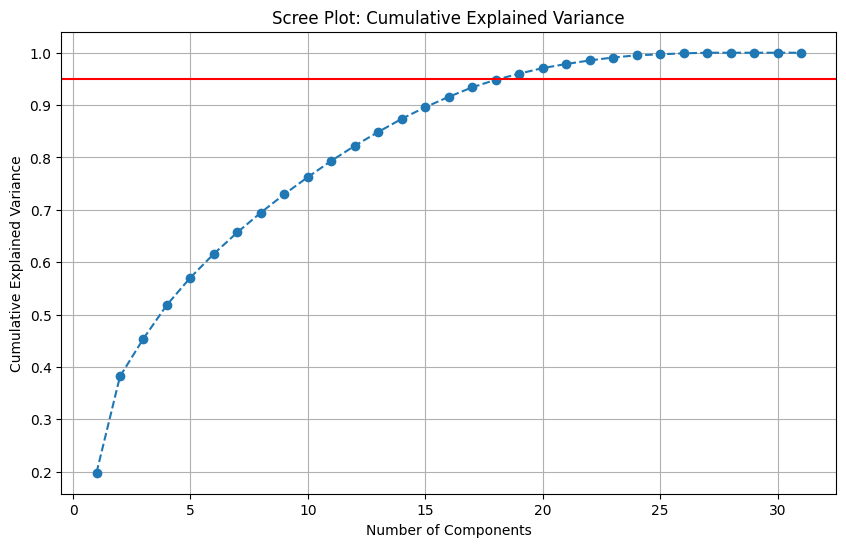

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load your data (replace with your actual filename)
df = merged_df.copy(deep=True)

# 2. Preprocessing: Drop non-numeric cols and Handle NaNs
# Trees handle NaNs, but PCA does NOT. You must fill or drop them.
X = df.select_dtypes(include=['number']).fillna(0)

# 3. Standardize: CRITICAL for PCA 
# If one feature is 'Units' (1000s) and another is 'Price' (10s), PCA will be biased.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Run PCA
pca = PCA()
pca.fit(X_scaled)

# 5. Plot the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')

plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.95, color='r', linestyle='-') # 95% variance line
plt.grid()
plt.show()

In [50]:
import numpy as np
merged_df['big_deals_ratio']=merged_df['big_deals']/merged_df['Total_Units']
merged_df.drop(columns=['mfg_book_units'],inplace=True)
merged_df["Target"]=np.log1p(merged_df["Target"])

In [51]:
merged_df["PLID_masked"] = merged_df["PLID_masked"].astype("category")

In [52]:
merged_df.columns

Index(['PLID_masked', 'Year', 'Q', 'Time_Index', 'Education- Public/Private',
       'Energy/Utilities', 'Financial Services', 'Government', 'Health Care',
       'Hospitality/Hotels & Leisure', 'Manufacturing', 'Media/Entertainment',
       'Professional Services', 'Retail', 'Service Provider',
       'Technical Services', 'Transportation', 'Unknown',
       'Wholesale/Distribution', 'COMMERCIAL', 'ENTERPRISE', 'OTHER',
       'PUBLIC_SECTOR', 'SERVICE_PROVIDER', 'SMB', 'Total_Units', 'lag_1',
       'lag_2', 'Target', 'big_deals', 'avg_deals', 'big_deals_ratio'],
      dtype='object')

In [53]:
merged_df[["big_deals", "avg_deals", "big_deals_ratio"]] = \
merged_df[["big_deals", "avg_deals", "big_deals_ratio"]].fillna(0)

In [54]:
merged_df["has_deals_data"] = (merged_df["big_deals"] > 0).astype(int)

In [55]:
merged_df.to_csv("temp2.csv")

In [56]:
import pandas as pd
import numpy as np

# ===============================
# STEP 0: PREP DATA
# ===============================

df = merged_df.copy()
df.columns = df.columns.str.replace(" ", "_")
df = df.sort_values(["PLID_masked", "Time_Index"])

# TRAIN DATA (has target)
train_df = df[df["Target"].notna()].copy()

# FUTURE DATA (target missing → prediction set)
future_df = df[df["Target"].isna()].copy()
X = train_df.drop(columns=["PLID_masked", "Target", "Total_Units"], errors="ignore")
y = train_df["Target"]
future_plid = future_df["PLID_masked"]

X_future = future_df.drop(columns=["PLID_masked", "Target", "Total_Units"], errors="ignore")


# ===============================
# STEP 2: TRAIN MODELS
# ===============================

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None, # This uses all features per split
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# 2. XGBoost
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.2,
    max_depth=3,
    subsample=0.6,
    colsample_bytree=0.8,
    reg_alpha=5.0,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

# 3. LightGBM
lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.2,
    max_depth=15,
    num_leaves=50,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=5.0,
    reg_lambda=1.0,
    random_state=42,
    importance_type='gain'
)

rf.fit(X, y)
xgb.fit(X, y)
lgb.fit(X, y)

# ===============================
# STEP 4: PREDICT
# ===============================

rf_pred  = np.expm1(rf.predict(X_future))
xgb_pred = np.expm1(xgb.predict(X_future))
lgb_pred = np.expm1(lgb.predict(X_future))

# Ensemble
final_pred = (rf_pred + xgb_pred + lgb_pred) / 3


# ===============================
# STEP 5: BUILD FINAL OUTPUT
# ===============================

# Individual model outputs
rf_output = pd.DataFrame({
    "PLID_masked": future_plid,
    "RF_Prediction": rf_pred
}).sort_values("PLID_masked")


xgb_output = pd.DataFrame({
    "PLID_masked": future_plid,
    "XGB_Prediction": xgb_pred
}).sort_values("PLID_masked")


lgb_output = pd.DataFrame({
    "PLID_masked": future_plid,
    "LGB_Prediction": lgb_pred
}).sort_values("PLID_masked")


# Ensemble (stacked)
ensemble_output = pd.DataFrame({
    "PLID_masked": future_plid,
    "Ensemble_Prediction": final_pred
}).sort_values("PLID_masked")


# ===============================
# (Optional) COMBINED VIEW
# ===============================

all_predictions = rf_output.merge(xgb_output, on="PLID_masked") \
                           .merge(lgb_output, on="PLID_masked") \
                           .merge(ensemble_output, on="PLID_masked")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000508 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2476
[LightGBM] [Info] Number of data points in the train set: 334, number of used features: 30
[LightGBM] [Info] Start training from score 7.694223
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

In [57]:
all_predictions

,PLID_masked,RF_Prediction,XGB_Prediction,LGB_Prediction,Ensemble_Prediction
0,IP CONFERENCE PHONE,4173.791863,5874.586914,4140.956968,4729.778582
1,IP PHONE Enterprise Desk,13019.804200,17138.332031,21571.646761,17243.260997
2,ROUTER Branch 4-Port PoE,6860.860208,5831.265137,5684.315579,6125.480308
3,ROUTER Branch 8-Port PoE,1493.376513,2713.964600,1518.332856,1908.557990
4,ROUTER Edge Aggregation Fiber,868.427157,813.790039,1021.332966,901.183387
5,ROUTER Enterprise Edge 10G/40G,672.557642,813.836670,978.873095,821.755802
6,SECURITY FIREWALL Next-Generation_1,351.644622,336.454346,325.931786,338.010251
7,SECURITY FIREWALL Next-Generation_2,335.687891,346.830597,247.819984,310.112824
8,SWITCH Core 100G Fiber,654.739631,605.191833,621.997390,627.309618
9,SWITCH Core 100G/400G Fiber,235.365516,401.205078,313.897268,316.822621


In [58]:
all_predictions.to_csv("2026_preds.csv")

In [59]:
df = pd.read_excel(
    r"C:\Users\Prabhat\Desktop\Carear\Hackathons\CFL_External Data Pack_Phase1.ods",
    sheet_name="Data_Pack_-_Actual_Bookings",
    skiprows=1
)

In [60]:
df.rename(columns={"Unnamed: 0":"cost_rank","Unnamed: 1":"PLID_masked","Unnamed: 2":"product_life_cycle"},inplace=True)

In [61]:
df = df.drop(index=0)
df

,cost_rank,PLID_masked,product_life_cycle,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 12,Unnamed: 13,Unnamed: 14,Your Forecast FY26 Q2,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast,Unnamed: 19,Unnamed: 20,Unnamed: 21
1,1,SWITCH Enterprise 48-Port UPOE,Sustaining,21149,10584,16105,12434,9437,17530,18518,...,14395,18663,13144,NaN,15052.101882,14795.306069,17011.0,NaN,NaN,NaN
2,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,30498,40505,61214,41932,59424,60073,66952,...,87843,71494,58318,NaN,79000.0,66274.81571,79114.0,NaN,NaN,NaN
3,3,SWITCH Core 25G/100G Fiber,Sustaining,4680,4397,5065,4092,4573,5449,5801,...,5701,6784,6346,NaN,6620.962605,6739.907617,7861.0,NaN,NaN,NaN
4,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927,8358,11681,10461,9704,11345,9946,...,9436,10338,8433,NaN,9200.438118,10383.999801,9789.0,NaN,NaN,NaN
5,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349,67670,55237,53599,53108,51781,59560,...,53710,41524,43188,NaN,35588.0,44460.24672,49532.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,26,SWITCH Industrial 8-Port PoE Compact,0.755081,-0.244919,0.964957,-0.035043,0.938836,0.061164,NaN,0.755081,...,-0.364652,0.967576,0.032424,NaN,0.866076,-0.133924,0.686135,-0.313865,0.761975,0.238025
62,27,SWITCH Industrial Managed,0.996429,-0.003571,0.71648,-0.28352,0.868298,-0.131702,NaN,0.705804,...,-0.353701,0.932327,-0.067673,NaN,0.730804,-0.269196,0.688897,-0.311103,0.947944,0.052056
63,28,ROUTER Edge Aggregation Fiber,0.795334,-0.204666,0.911729,0.088271,0.0,1.068966,NaN,0.636267,...,-0.274486,0.706897,0.293103,NaN,0.95228,-0.04772,0.599758,0.400242,0.0,2.086207
64,29,SWITCH Industrial 24-Port PoE,0.594684,0.405316,0.464396,-0.535604,0.674157,-0.325843,NaN,0.817276,...,-0.280186,0.451685,-0.548315,NaN,0.358804,0.641196,0.665635,-0.334365,0.617978,-0.382022


In [62]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]


In [63]:
df = df.iloc[:30].reset_index(drop=True)


In [64]:
df = df.drop(index=5)


In [65]:
df.drop(columns=["cost_rank","Your Forecast FY26 Q2"],inplace=True)
df


,PLID_masked,product_life_cycle,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast
0,SWITCH Enterprise 48-Port UPOE,Sustaining,15052.101882,14795.306069,17011.0
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,79000.0,66274.81571,79114.0
2,SWITCH Core 25G/100G Fiber,Sustaining,6620.962605,6739.907617,7861.0
3,SWITCH Enterprise 24-Port PoE+,Sustaining,9200.438118,10383.999801,9789.0
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,35588.0,44460.24672,49532.0
6,SWITCH Enterprise 48-Port Fiber (Non-PoE),Sustaining,2007.71937,2329.190353,1968.0
7,SWITCH Enterprise 25G Fiber,Sustaining,3035.040651,3362.0419,2868.0
8,SWITCH Enterprise 24-Port UPOE,Sustaining,2754.898797,2894.341372,2463.0
9,ROUTER Enterprise Edge 10G/40G,Decline,431.0,350.0,732.0
10,SECURITY FIREWALL Next-Generation_2,Sustaining,309.99938,321.468,252


In [66]:
df=pd.merge(df,all_predictions,how="inner",on="PLID_masked")

In [67]:
df.columns

Index(['PLID_masked', 'product_life_cycle', 'Demand Planners' Forecast',
       'Marketing Team's Forecast ', 'Data Science Team's Forecast',
       'RF_Prediction', 'XGB_Prediction', 'LGB_Prediction',
       'Ensemble_Prediction'],
      dtype='object')

In [68]:
# ================================
# STEP 1: Metric function
# ================================
num_cols = [
    "RF_Prediction", "XGB_Prediction", "LGB_Prediction", "Ensemble_Prediction",
    "Demand Planners' Forecast", "Marketing Team's Forecast ", "Data Science Team's Forecast"
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
def compute_metrics(pred, actual):
    bias = (pred - actual) / actual
    accuracy = (1 - abs(bias)).clip(lower=0)
    return accuracy


# ================================
# STEP 2: Model list
# ================================

models = ["RF_Prediction", "XGB_Prediction", "LGB_Prediction", "Ensemble_Prediction"]

teams = {
    "DP": "Demand Planners' Forecast",
    "MKT": "Marketing Team's Forecast ",
    "DS": "Data Science Team's Forecast"
}


# ================================
# STEP 3: Compute metrics
# ================================

for model in models:
    for key, team_col in teams.items():

        acc_col = f"{model}_Accuracy_{key}"
        
        df[acc_col] = compute_metrics(
            df[model],
            df[team_col]
        )


# ================================
# STEP 4: Convert to percentage
# ================================

for col in df.columns:
    if "Bias" in col or "Accuracy" in col:
        df[col] = (df[col] * 100).round(2)


# ================================
# STEP 5: Average comparison
# ================================

summary = {}

for model in models:
    summary[model] = {}
    for key in teams.keys():
        acc_col = f"{model}_Accuracy_{key}"   # FIXED (* → _)
        summary[model][f"Avg_Accuracy_{key}"] = df[acc_col].mean()

summary_df = pd.DataFrame(summary).T

print(summary_df)


# ================================
# STEP 6: Final preview
# ================================

df.head()

                     Avg_Accuracy_DP  Avg_Accuracy_MKT  Avg_Accuracy_DS
RF_Prediction              78.922069         63.830690        79.426207
XGB_Prediction             65.092759         56.660345        75.507931
LGB_Prediction             73.262414         61.904828        84.231379
Ensemble_Prediction        72.701379         61.667586        82.794828


,PLID_masked,product_life_cycle,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast,RF_Prediction,XGB_Prediction,LGB_Prediction,Ensemble_Prediction,RF_Prediction_Accuracy_DP,...,RF_Prediction_Accuracy_DS,XGB_Prediction_Accuracy_DP,XGB_Prediction_Accuracy_MKT,XGB_Prediction_Accuracy_DS,LGB_Prediction_Accuracy_DP,LGB_Prediction_Accuracy_MKT,LGB_Prediction_Accuracy_DS,Ensemble_Prediction_Accuracy_DP,Ensemble_Prediction_Accuracy_MKT,Ensemble_Prediction_Accuracy_DS
0,SWITCH Enterprise 48-Port UPOE,Sustaining,15052.101882,14795.306069,17011.0,14630.690521,22192.019531,16950.963004,17924.557685,97.20,...,86.01,52.57,50.01,69.54,87.38,85.43,99.65,80.92,78.85,94.63
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,79000.000000,66274.815710,79114.0,49683.610880,81481.351562,67717.528929,66294.163790,62.89,...,62.80,96.86,77.06,97.01,85.72,97.82,85.59,83.92,99.97,83.80
2,SWITCH Core 25G/100G Fiber,Sustaining,6620.962605,6739.907617,7861.0,6339.264132,7670.157715,7788.707485,7266.043110,95.75,...,80.64,84.15,86.20,97.57,82.36,84.44,99.08,90.26,92.19,92.43
3,SWITCH Enterprise 24-Port PoE+,Sustaining,9200.438118,10383.999801,9789.0,9064.175679,8658.448242,10439.910006,9387.511309,98.52,...,92.60,94.11,83.38,88.45,86.53,99.46,93.35,97.97,90.40,95.90
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,35588.000000,44460.246720,49532.0,49128.791824,62094.714844,54093.746536,55105.751068,61.95,...,99.19,25.52,60.34,74.64,48.00,78.33,90.79,45.16,76.06,88.75


In [69]:
df

,PLID_masked,product_life_cycle,Demand Planners' Forecast,Marketing Team's Forecast,Data Science Team's Forecast,RF_Prediction,XGB_Prediction,LGB_Prediction,Ensemble_Prediction,RF_Prediction_Accuracy_DP,...,RF_Prediction_Accuracy_DS,XGB_Prediction_Accuracy_DP,XGB_Prediction_Accuracy_MKT,XGB_Prediction_Accuracy_DS,LGB_Prediction_Accuracy_DP,LGB_Prediction_Accuracy_MKT,LGB_Prediction_Accuracy_DS,Ensemble_Prediction_Accuracy_DP,Ensemble_Prediction_Accuracy_MKT,Ensemble_Prediction_Accuracy_DS
0,SWITCH Enterprise 48-Port UPOE,Sustaining,15052.101882,14795.306069,17011.0,14630.690521,22192.019531,16950.963004,17924.557685,97.20,...,86.01,52.57,50.01,69.54,87.38,85.43,99.65,80.92,78.85,94.63
1,WIRELESS ACCESS POINT WiFi6E (Internal Antenna...,Sustaining,79000.000000,66274.815710,79114.0,49683.610880,81481.351562,67717.528929,66294.163790,62.89,...,62.80,96.86,77.06,97.01,85.72,97.82,85.59,83.92,99.97,83.80
2,SWITCH Core 25G/100G Fiber,Sustaining,6620.962605,6739.907617,7861.0,6339.264132,7670.157715,7788.707485,7266.043110,95.75,...,80.64,84.15,86.20,97.57,82.36,84.44,99.08,90.26,92.19,92.43
3,SWITCH Enterprise 24-Port PoE+,Sustaining,9200.438118,10383.999801,9789.0,9064.175679,8658.448242,10439.910006,9387.511309,98.52,...,92.60,94.11,83.38,88.45,86.53,99.46,93.35,97.97,90.40,95.90
4,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,35588.000000,44460.246720,49532.0,49128.791824,62094.714844,54093.746536,55105.751068,61.95,...,99.19,25.52,60.34,74.64,48.00,78.33,90.79,45.16,76.06,88.75
5,SWITCH Enterprise 48-Port Fiber (Non-PoE),Sustaining,2007.719370,2329.190353,1968.0,2676.773092,2692.866211,2525.919455,2631.852919,66.68,...,63.99,65.87,84.39,63.17,74.19,91.55,71.65,68.91,87.01,66.27
6,SWITCH Enterprise 25G Fiber,Sustaining,3035.040651,3362.041900,2868.0,3842.860120,2991.308350,3156.228533,3330.132334,73.38,...,66.01,98.56,88.97,95.70,96.01,93.88,89.95,90.28,99.05,83.89
7,SWITCH Enterprise 24-Port UPOE,Sustaining,2754.898797,2894.341372,2463.0,2525.188972,2131.932617,2103.209620,2253.443736,91.66,...,97.48,77.39,73.66,86.56,76.34,72.67,85.39,81.80,77.86,91.49
8,ROUTER Enterprise Edge 10G/40G,Decline,431.000000,350.000000,732.0,672.557642,813.836670,978.873095,821.755802,43.95,...,91.88,11.17,0.00,88.82,0.00,0.00,66.27,9.34,0.00,87.74
9,SECURITY FIREWALL Next-Generation_2,Sustaining,309.999380,321.468000,252.0,335.687891,346.830597,247.819984,310.112824,91.71,...,66.79,88.12,92.11,62.37,79.94,77.09,98.34,99.96,96.47,76.94
